**Prepared by: Tim Hayes**

**Cohort: GEN-AI-MSFT-JUN24**'

# **Project : A Case Study of ExpressWay Logistics**

**Business Overview:**

ExpressWay Logistics is a dynamic logistics service provider, committed to delivering efficient, reliable and cost-effective courier transportation and warehousing solutions. With a focus on speed, precision and customer satisfaction, we aim to be the go-to partner for our customers seeking seamless courier services. Our core service involves ensuring operational efficiency throughout our delivery and courier services, including inventory management, durable packaging and swift dispatch of couriers, real time tracking of shipments and on-time delivery of couriers as promised. We are committed to enhance our logistics and courier services and improve seamless connectivity for our customers.

**Current Challenge:**

ExpressWay Logistics faces numerous challenges in ensuring seamless deliveries and customer satisfaction. These challenges include managing various customer demands simultaneously, addressing delays in deliveries and ensuring products arrive intact and safe. Additionally, the company struggles with complexity of efficiently storing and handling a large volume of packages and ultimately meeting customer expectations. Moreover, maintaining a skilled workforce capable of handling various aspects of logistics operations presents its own set of challenges. Overcoming these obstacles requires a comprehensive approach that integrates innovative technology, strategic planning, and continuous improvement initiatives to ensure smooth operations and exceptional service delivery.

**Objective:**

Our primary objective is to conduct a sentiment analysis of user-generated reviews across various digital channels and platforms. By paying attention to their feedback, we want to find ways to make our services better - like handling different customer demands simultaneously, dealing with late deliveries, and keeping packages secured and intact. Through the application of prompt engineering methodologies and sentiment analysis, we'll figure out if sentiments expressed by users for our courier services are Positive or Negative. This will help us understand where we need to improve in order to meet customer expectations and keep them happy. With a focus on getting better all the time, we'll overcome the challenges at ExpressWay Logistics and make our services the best.

**Data Description:**

The dataset titled "courier-service_reviews.csv" is structured to facilitate sentiment analysis for courier service reviews. Here's a brief description of the data columns:

1. id: This column contains unique identifiers for each review entry. It helps in distinguishing and referencing individual reviews.
2. review: This column includes the actual text of the courier service reviews. The reviews are likely composed of customer opinions and experiences regarding different aspects of the services provided by ExpressWay Logistics.
3. sentiment: This column provides an additional layer of classification (positive and negative) for the mentioned reviews.

##**Step 1. Setup (2 Marks)**

(A) Writing/Creating the config.json file  (2 Marks)

### Installation

In [144]:
#!pip install openai==1.2 tiktoken datasets session-info --quiet

# I prefer to use conda environment and visual code. Below are my required conda/pip commands that include additional packages I utilized:
# !conda create --name gl-project2 -y python=3.8 pandas numpy scikit-learn tqdm session-info tabulate seaborn matplotlib wordcloud -y
# !conda activate gl-project2
# !pip install openai==1.2 tiktoken --quiet

### Imports

In [145]:
# Import all Python packages required to access the Azure Open AI API.
# Import additional packages required to access datasets and create examples.

from openai import AzureOpenAI
import json
import re
import tiktoken
import session_info

import pandas as pd
import numpy as np

from collections import Counter
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from tabulate import tabulate


import seaborn as sns                                   # Import seaborn
import matplotlib.pyplot as plt                         # Import Matplotlib
from wordcloud import WordCloud,STOPWORDS               # Import WorldCloud and Stopwords

import string

In [146]:
session_info.show()

### Authentication

**(A) Load credentials from config.json file (2 Marks)**

In [149]:
with open('config.json', 'r') as az_creds:
    data = az_creds.read()

In [150]:
creds = json.loads(data)

# # Check if all required keys are present in the creds dictionary
required_keys = ["AZURE_OPENAI_ENDPOINT", "AZURE_OPENAI_KEY", "AZURE_OPENAI_APIVERSION", "CHATGPT_MODEL"]
missing_keys = [key for key in required_keys if key not in creds]

# If there are missing keys, raise an exception
if missing_keys:
    raise KeyError(f"The following required keys are missing from the creds dictionary: {', '.join(missing_keys)}")
else:
    print("All required keys were found in config.json")

All required keys were found in config.json


In [151]:
client = AzureOpenAI(
    azure_endpoint=creds["AZURE_OPENAI_ENDPOINT"],
    api_key=creds["AZURE_OPENAI_KEY"],
    api_version=creds["AZURE_OPENAI_APIVERSION"]
)

In [152]:
chat_model_id = creds["CHATGPT_MODEL"]

### Useful Graphical Functions

In [153]:
def output_wordcloud(data, title, sentiment):
    '''Output a wordcloud and top 20 most frequent words excluding custom stopwords
        data: dataframe
        title: Title of wordcloud
        sentiment: Sentiment to filter on
    '''
    # Filter the reviews
    reviews = data[data['sentiment'] == sentiment]['review']
    words = ' '.join(reviews)
    
    # Additional cleaning of the text to remove punctuation
    words = words.translate(str.maketrans('', '', string.punctuation)).lower()

    # Stop words to avoid for this dataset in Wordcloud's algorithm
    custom_stopwords = STOPWORDS.union({'to', 'and', 'the', 'my', 'of', 'expressway', 'logistics', 'despite'})
    
    # Create the WordCloud object with the custom stopwords
    wordcloud = WordCloud(stopwords=custom_stopwords,
                          colormap='RdBu',
                          background_color='black',
                          width=2000,
                          height=1500
                         ).generate(words)

    # Display WordCloud
    plt.figure(1, figsize=(8, 8), frameon='equal')
    plt.title(title, fontsize=20)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

    # Clean the word list before counting word frequencies
    word_list = [word for word in words.split() if word.lower() not in custom_stopwords]
    word_counts = Counter(word_list)

    # Get the top 5 most frequent words
    top_five_words = word_counts.most_common(5)

    print("\nTop 5 Most Frequent Words (excluding stopwords):")
    for word, count in top_five_words:
        print(f'{word}: {count}')

def output_pretty_classification_report(y_true, y_pred, title="Classification Report"):
    """
    Generate and display the classification report as a styled pandas DataFrame.
    y_true: The ground truth labels
    y_pred: The predicted labels
    """
    # Generate the classification report as a dictionary
    report_dict = classification_report(y_true, y_pred, output_dict=True)

    # Convert the classification report dictionary to a pandas DataFrame
    report_df = pd.DataFrame(report_dict).transpose()

    # Apply formatting to highlight precision, recall, and F1-score
    styled_report = (report_df.style
                     .format("{:.2f}")
                     .background_gradient(subset=["precision", "recall", "f1-score"], cmap="Blues")
                     .set_caption(title)
                     .set_properties(**{'text-align': 'center'})
                    )

    display(styled_report)

def output_pretty_countplot(df, x, order=None, hue=None, figsize=None, title=None, re_orient=False):
    '''Output a customized nice looking standardized countplot
        :df: DataFrame to use
        :x: The x axis variable to use in the plot
        :order: The y axis variable to use in the plot default is None
        :hue: The hue variable to use in the plot default is None
        :figsize: The figure size tuple to use in the plot default is None
        :title: The title to use default is Countplot: for {}
    ''' 
    
    if (title is None):
        title = 'Countplot: for {}'.format(x)
    
        if (hue is not None):
            title += ' with hue of {}'.format(hue)
        
    # Use default figsize if not provided
    if (figsize is None):
        figsize=(15,3.5);
        
    plt.figure(figsize=figsize);
        
    plt.xticks(rotation=45);
    plt.rcParams["figure.figsize"] = [7.0, 3.5]
    plt.rcParams["figure.autolayout"] = True
       
    # Ouput count plot
    if (re_orient):
        ax = sns.countplot(data=df,y=x,order=order,hue=hue);  
    else:
        ax = sns.countplot(data=df,x=x,order=order,hue=hue);  
        
    # output the amounts on top of the bars
    for p in ax.patches:
        if (re_orient):
            x = p.get_x() + p.get_width() + (p.get_width()*0.04) + .25
            y = p.get_y() + p.get_height()          
        else:
            x = p.get_x() + p.get_width() / 2
            y = p.get_y() + p.get_height() + (p.get_height()*0.01)
            
        value = '{:.1f}'.format(p.get_height()) if re_orient == False else '{:.1f}'.format(p.get_width())
        
        if (pd.isna(x) or pd.isna(y) or pd.isna(value)):
            continue
  
        ax.text(x, y, value, ha="center")

    plt.title(title);
    plt.show();

def output_pretty_numeric_plots(df, feature, title=None):
    '''Output a customized boxplot and histplot
    :df: DataFrame to use
    :feature: the feature to plot
    :title_suffix: title suffix to append, default is ''
    ''' 
    print(df[feature].describe())
    
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})

    sns.boxplot(data=df, x=feature, ax=ax_box,showmeans=True)
    sns.histplot(data=df, x=feature, kde=True, ax=ax_hist)

    # Add title to the histogram plot
    if title is None:
        title = "Distribution for {}".format(feature)
        
    ax_hist.set_title(title)

    # Show the plots
    plt.tight_layout()
    plt.show()

### Utilities

In [154]:
def num_tokens_from_messages(messages):

    """
    Return the number of tokens used by a list of messages.
    Adapted from the Open AI cookbook token counter
    """

    encoding = tiktoken.encoding_for_model("gpt-3.5-turbo")

    # Each message is sandwiched with <|start|>role and <|end|>
    # Hence, messages look like: <|start|>system or user or assistant{message}<|end|>

    tokens_per_message = 3 # token1:<|start|>, token2:system(or user or assistant), token3:<|end|>

    num_tokens = 0

    for message in messages:
        num_tokens += tokens_per_message
        for key, value in message.items():
            num_tokens += len(encoding.encode(value))

    num_tokens += 3  # every reply is primed with <|start|>assistant<|message|>

    return num_tokens
    
def get_chat_response(input_description, chat_model_id, client, prompt_list, user_message_template, temperature=0, max_tokens=2):
    """
    A generic reusable function to generate chat response from a model for zero-shot, few-shot, and COTS prompts.

    Parameters:
    - input_description (str): The description or input data for the chat completion.
    - chat_model_id (str): The model ID for the chat model.
    - client (object): The API client for communicating with the model (e.g., Azure or OpenAI).
    - prompt_list (list): A list of prompts to be included in the input message (zero-shot, few-shot, or COTS).
    - user_message_template (str): Template string to format user input message.
    - temperature (float): Controls randomness in the model’s output. Default is 0.
    - max_tokens (int): The maximum number of tokens the model can generate. Default is 4.

    Returns:
    - str: The response content from the model.
    """
    user_input = [
        {
            'role': 'user',
            'content': user_message_template.format(courier_service_review=input_description)
        }
    ]
    
    response = client.chat.completions.create(
        model=chat_model_id,
        messages=prompt_list + user_input,
        temperature=temperature,
        max_tokens=max_tokens
    )
    
    return response.choices[0].message.content

def calculate_mean_and_stdev(numbers):
    """
    This function takes a list of numbers and returns the mean and standard deviation.

    Parameters:
    numbers (list): A list of numerical values.

    Returns:
    tuple: A tuple containing the mean and standard deviation of the list.
    """

    # Calculate the mean using numpy's mean function
    mean = np.mean(numbers)

    # Calculate the standard deviation using numpy's std function
    stdev = np.std(numbers)

    # Return both mean and standard deviation as a tuple
    return mean, stdev

def create_examples(dataset, n=4):

    """
    Return a JSON list of randomized examples of size 2n with two classes.
    Create subsets of each class, choose random samples from the subsets,
    merge and randomize the order of samples in the merged list.
    Each run of this function creates a different random sample of examples
    chosen from the training data.

    Args:
        dataset (DataFrame): A DataFrame with examples (review + label)
        n (int): number of examples of each class to be selected

    Output:
        randomized_examples (JSON): A JSON with examples in random order
    """

    positive_reviews = (dataset.sentiment == 'Positive')
    negative_reviews = (dataset.sentiment == 'Negative')
    columns_to_select = ['review', 'sentiment']

    positive_examples = dataset.loc[positive_reviews, columns_to_select].sample(n)
    negative_examples = dataset.loc[negative_reviews, columns_to_select].sample(n)

    examples = pd.concat([positive_examples, negative_examples])

    # sampling without replacement is equivalent to random shuffling
    randomized_examples = examples.sample(2*n, replace=False)

    return randomized_examples.to_json(orient='records')
    
def create_prompt(system_message, examples, user_message_template, verbose=True):

    """
    Return a prompt message in the format expected by the Open AI API.
    Loop through the examples and parse them as user message and assistant
    message.

    Args:
        system_message (str): system message with instructions for sentiment analysis
        examples (str): JSON string with list of examples
        user_message_template (str): string with a placeholder for courier service reviews
        verbose: True by default will output completed prompt

    Output:
        few_shot_prompt (List): A list of dictionaries in the Open AI prompt format
    """

    few_shot_prompt = [{'role':'system', 'content': system_message}]

    for example in json.loads(examples):
        example_review = example['review']
        example_sentiment = example['sentiment']

        few_shot_prompt.append(
            {
                'role': 'user',
                'content': user_message_template.format(
                    courier_service_review=example_review
                )
            }
        )

        few_shot_prompt.append(
            {'role': 'assistant', 'content': f"{example_sentiment}"}
        )

    number_of_tokens = num_tokens_from_messages(few_shot_prompt)
    if (verbose):
        print("{}\nNumber of tokens: {}".format(few_shot_prompt, number_of_tokens))
          
    return few_shot_prompt, number_of_tokens

def evaluate_prompt(prompt, gold_examples, user_message_template, temperature=0, max_tokens=2, chat_model_id="gpt-4o-mini", verbose=False):

    """
    Return the micro-F1 score for predictions on gold examples.
    For each example, we make a prediction using the prompt. Gold labels and
    model predictions are aggregated into lists and compared to compute the
    F1 score.

    Args:
        prompt (List): list of messages in the Open AI prompt format
        gold_examples (str): JSON string with list of gold examples
        user_message_template (str): string with a placeholder for courier service review
        temperature: Temp to use in chat completions default to 0
        max_tokens: Max tokens to use in chat completion default 2
        chat_model_id: Chat model to use default to gpt-40-mini
        verbose: If true output table data default to False

    Output:
        micro_f1_score (float): Micro-F1 score computed by comparing model predictions
                                with ground truth
    """

    model_predictions, ground_truths, review_texts = [], [], []

    for example in json.loads(gold_examples):
        gold_input = example['review']
        user_input = [
            {
                'role':'user',
                'content': user_message_template.format(courier_service_review=gold_input)
            }
        ]

        try:
            response = client.chat.completions.create(
                model=chat_model_id,
                messages=prompt+user_input,
                temperature=temperature, # <- Note the low temperature (For a deterministic response)
                max_tokens=max_tokens, # <- Note how we restrict the output to not more than 2 tokens
                top_p=0.05           # A lower value (like 0.1) will limit the model to choose from only the most likely tokens, making the response more deterministic.

            )

            prediction = response.choices[0].message.content
            # <- removes extraneous white spaces and puncatuation
            prediction = re.sub(r'[^\w]', '', prediction)

            if (prediction not in ["Positive", "Negative"]):
                print("Prediction *{}* Failing prompt {}".format(prediction, prompt))
                
            model_predictions.append(prediction)
            ground_truths.append(example['sentiment'])
            review_texts.append(gold_input)

        except Exception as e:
            print(f"An error occurred in evaluate_prompt: {e}")

    micro_f1_score = f1_score(ground_truths, model_predictions, average="micro")

    if verbose:
        table_data = [[text, pred, truth] for text, pred, truth in zip(review_texts, model_predictions, ground_truths)]
        headers = ["Review", "Model Prediction", "Ground Truth"]
        print(tabulate(table_data, headers=headers, tablefmt="grid"))

    return micro_f1_score,ground_truths, model_predictions

def run_multiple_evaluations(cs_examples_df, zero_shot_system_message, few_shot_system_message, gold_examples, user_message_template, 
                             num_eval_runs = 5):
    """
    This function evaluates the performance of a sentiment analysis model in both zero-shot and few-shot modes
    over multiple evaluation runs. It creates prompts using a dynamic selection of examples, then measures 
    the Micro F1 score for both zero-shot and few-shot prompts based on gold examples.

    Parameters:
    - cs_examples_df (DataFrame): DataFrame containing the customer service examples used for prompt creation.
    - zero_shot_system_message (str): The system message used for zero-shot evaluation.
    - few_shot_system_message (str): The system message used for few-shot evaluation.
    - gold_examples (list): A set of manually labeled gold examples for evaluating the performance of the model.
    - user_message_template (str): Template for user messages that are integrated into the prompt.
    - num_eval_runs (int): Number of evaluation runs to perform (default is 5).

    Returns:
    - zero_shot_performance (list): List of Micro F1 scores for zero-shot evaluations.
    - few_shot_performance (list): List of Micro F1 scores for few-shot evaluations.
    """

    # Lists to store performance results of each run for both zero-shot and few-shot evaluations.
    zero_shot_performance = []
    few_shot_performance = []

    # In zero-shot prompt, the model does not get specific examples to guide it only the system message.
    zero_shot_prompt = [{'role':'system', 'content': zero_shot_system_message}]
    
    # Run the evaluation for a specified number of iterations
    for _ in tqdm(range(num_eval_runs)):  # tqdm is used to show a progress bar for evaluation runs

         # Evaluate the zero-shot prompt's performance by measuring the Micro F1 score on the gold examples
        zero_shot_micro_f1, ground_truths, model_predictions = evaluate_prompt(zero_shot_prompt, gold_examples, user_message_template)

        # Output a classification report for the zero shot prompt
        output_pretty_classification_report(ground_truths, model_predictions, title="Run Multiple Classification Report for zero shot prompt")

        # If the few shot prompt is not None then run it. This allows us to run zero shot only evals
        if (few_shot_system_message is not None):

           # For each run, create a new random sample of examples (typically for the few-shot prompt)
            examples = create_examples(cs_examples_df, 4)  # Creates 4 new examples for evaluation
        
            # Assemble the few-shot prompt using the few-shot system message and the randomly selected examples, In few-shot prompt, 
            # the model is provided with specific examples (in 'examples') to guide the prompt.
            few_shot_prompt, _ = create_prompt(few_shot_system_message, examples, user_message_template, verbose=True)

            # Evaluate the few-shot prompt's performance by measuring the Micro F1 score on the gold examples
            few_shot_micro_f1, ground_truths, model_predictions = evaluate_prompt(few_shot_prompt, gold_examples, user_message_template)

            # Output a classification report for the few shot prompt
            output_pretty_classification_report(ground_truths, model_predictions, title="Run Multiple Classification Report for few shot prompt")

            few_shot_performance.append(few_shot_micro_f1)

        zero_shot_performance.append(zero_shot_micro_f1)

    return zero_shot_performance, few_shot_performance

## Task : Sentiment Analysis

##**Step 2: Assemble Data (5 Marks)**

(A) Upload and Read csv File (2 Marks)

(B) Count Positive and Negative Sentiment Reviews (1 Marks)

(C) Split the Dataset (2 Marks)

**(A) Upload and read csv file (2 Marks)**

In [155]:
# Read the csv file
cs_reviews_df = pd.read_csv("courier-service_reviews.csv")

In [156]:
cs_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         131 non-null    int64 
 1   review     131 non-null    object
 2   sentiment  131 non-null    object
dtypes: int64(1), object(2)
memory usage: 3.2+ KB


#### Observations
- Data set has three columns id, review and sentiment.
- We will be focused on review and sentiment columns.

In [157]:
cs_reviews_df.sample(5)

,id,review,sentiment
23,24,The tracking system used by ExpressWay Logisti...,Negative
115,116,ExpressWay Logistics has been my go-to courier...,Negative
13,14,What sets ExpressWay Logistics apart from othe...,Positive
36,37,ExpressWay Logistics consistently delivers on ...,Positive
31,32,The packaging provided by ExpressWay Logistics...,Positive


#### Observations
- From the sample it appears that the sentiment is either Positive or Negative.

In [158]:
# Count null values per column and print with column name
for column, null_count in cs_reviews_df.isnull().sum().items():
    print(f"Column '{column}' has {null_count} null value(s)")

Column 'id' has 0 null value(s)
Column 'review' has 0 null value(s)
Column 'sentiment' has 0 null value(s)


#### Observations
- There are no nulls in the dataset.

In [159]:
# Find the unique values in the Sentiment column
unique_values = cs_reviews_df['sentiment'].unique().tolist()
print(unique_values)

['Positive', 'Negative']


#### Observations
- The sentiment columns contains the unique values for Positive and Negative.

**(B) Count Positive and Negative Sentiment Reviews (1 Marks)**

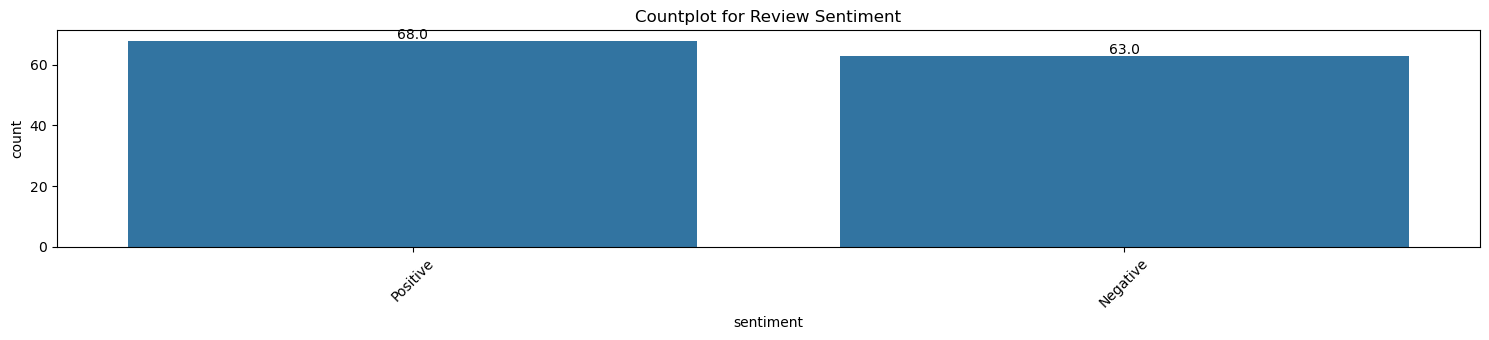

sentiment
Positive    0.519084
Negative    0.480916
Name: proportion, dtype: float64

In [160]:
# Countplot for customer reviews
feature = 'sentiment'
output_pretty_countplot(cs_reviews_df, feature, \
                        order=cs_reviews_df[feature].value_counts().index, title="Countplot for Review Sentiment")
cs_reviews_df[feature].value_counts(normalize=True)

#### Observations
- We can see that the review have 51.9% positive sentiment and 48% negative.
- From this we can deduce the dataset is slightly imbalanced which we need to address during our evaluation.

In [161]:
cs_reviews_df.shape

(131, 3)

#### Observations
- Dataset has 131 rows.

**(C) Split the Dataset (2 Marks)**

Lets split first without stratify even though the dataset is imbalanced.

In [162]:
cs_examples_df, cs_gold_examples_df = train_test_split(
    cs_reviews_df, #<- the full dataset
    test_size=0.2, #<- 20% random sample selected for gold examples
    random_state=42 #<- ensures that the splits are the same for every session
)

Now we will stratify which should lead to more balanced performance of the model since the dataset is slightly imbalanced.

In [163]:
cs_examples_stratify_df, cs_gold_examples_stratify_df = train_test_split(
    cs_reviews_df, #<- the full dataset
    test_size=0.2, #<- 20% random sample selected for gold examples
    random_state=42, #<- ensures that the splits are the same for every session
    stratify=cs_reviews_df['sentiment'] # <- ensures the train and test sets maintain class balance
)

In [164]:
(cs_examples_df.shape, cs_gold_examples_df.shape)

((104, 3), (27, 3))

In [165]:
(cs_examples_stratify_df.shape, cs_gold_examples_stratify_df.shape)

((104, 3), (27, 3))

#### Observations
- Both the stratified and the non-stratified split have 104 rows in examples and 27 rows in the gold examples.

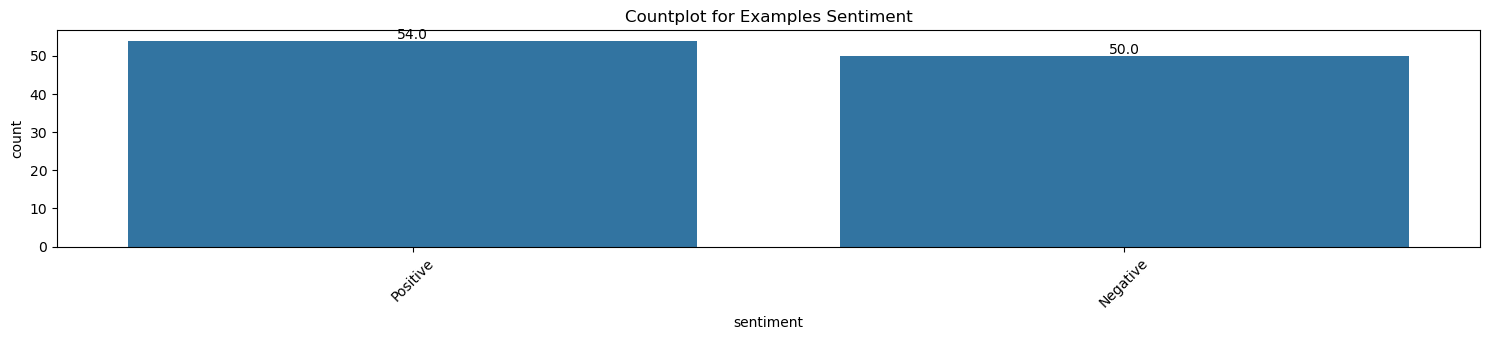

sentiment
Positive    0.519231
Negative    0.480769
Name: proportion, dtype: float64

In [166]:
# Countplot for example customer reviews
feature = 'sentiment'
output_pretty_countplot(cs_examples_df, feature, \
                        order=cs_examples_df[feature].value_counts().index, title="Countplot for Examples Sentiment")
cs_examples_df[feature].value_counts(normalize=True)

#### Observations
- There Positive class has a count of 54 (51.9%) and the Negative class has a count of 50 (48%) showing a slight imbalance.

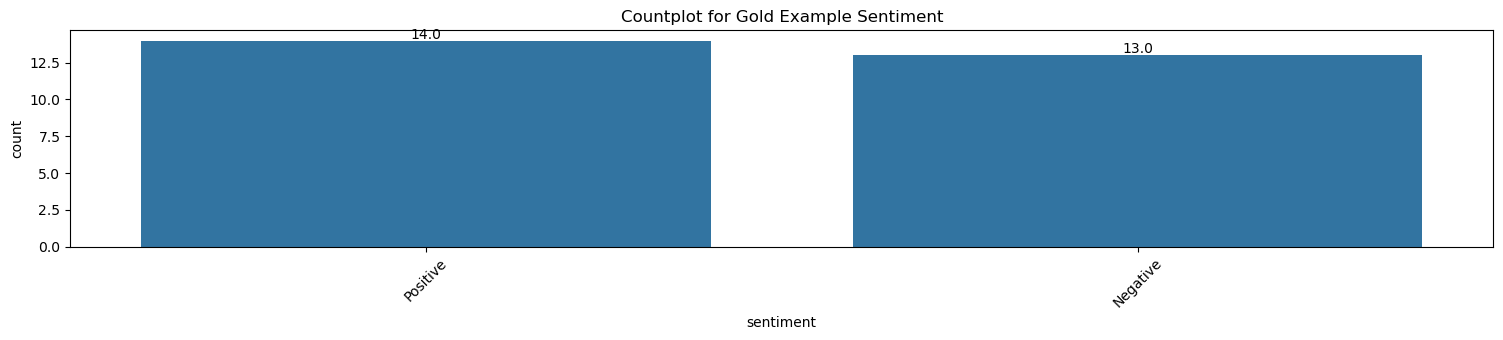

sentiment
Positive    0.518519
Negative    0.481481
Name: proportion, dtype: float64

In [167]:
# Countplot for gold example customer reviews
feature = 'sentiment'
output_pretty_countplot(cs_gold_examples_df, feature, \
                        order=cs_gold_examples_df[feature].value_counts().index, title="Countplot for Gold Example Sentiment")
cs_gold_examples_df[feature].value_counts(normalize=True)

#### Observations
- There Positive class has a count of 14 (51.8%) and the Negative class has a count of 13 (48%) showing a slight imbalance.

Let's take a look at the length of the reviews

count    131.000000
mean     315.427481
std      128.397402
min       94.000000
25%      206.500000
50%      283.000000
75%      420.000000
max      691.000000
Name: review_length, dtype: float64


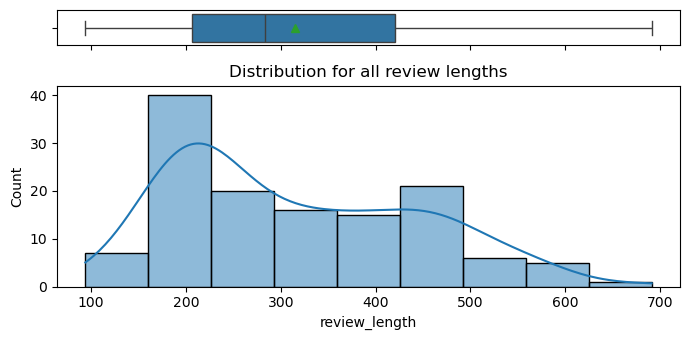

In [168]:
cs_reviews_df['review_length'] = cs_reviews_df['review'].apply(len)
output_pretty_numeric_plots(cs_reviews_df, 'review_length', "Distribution for all review lengths")

count     68.000000
mean     287.941176
std      120.432911
min       94.000000
25%      194.000000
50%      242.000000
75%      377.500000
max      572.000000
Name: review_length, dtype: float64


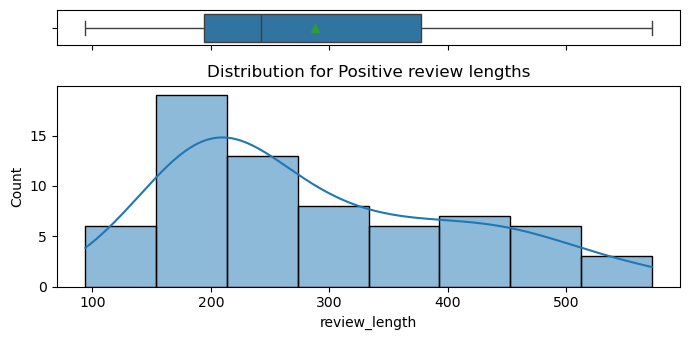

In [169]:
# Let's plot the Positive review distribution
output_pretty_numeric_plots(cs_reviews_df[cs_reviews_df['sentiment'] == 'Positive'], 'review_length', "Distribution for Positive review lengths")

count     63.000000
mean     345.095238
std      131.036035
min      180.000000
25%      213.500000
50%      333.000000
75%      456.500000
max      691.000000
Name: review_length, dtype: float64


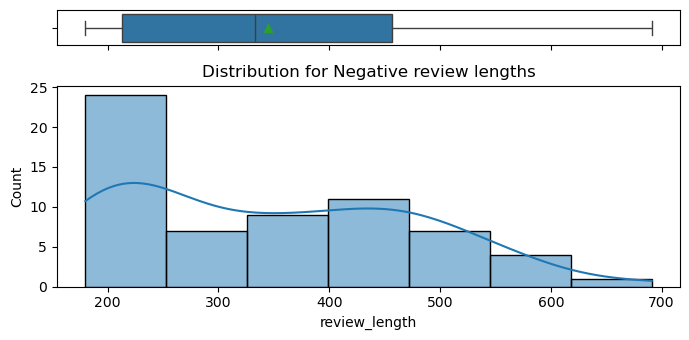

In [170]:
# Let's plot the Positive review distribution
output_pretty_numeric_plots(cs_reviews_df[cs_reviews_df['sentiment'] == 'Negative'], 'review_length', "Distribution for Negative review lengths")

#### Observations
- On average, Negative reviews are longer than Positive reviews (345.09 vs. 287.94 characters). This suggests that users who leave Negative reviews tend to provide more detailed feedback, possibly explaining their dissatisfaction more thoroughly.
- The standard deviation for Negative reviews (131.03) is higher than that for Positive reviews (120.43), meaning there is more variation in the length of Negative reviews. Some Negative reviews may be quite detailed, while others are more concise.
- The Positive vs Negative review length statistics could potentially help to differentiate between Positive and Negative classes although this dataset is quite small.

To select gold examples for this session, we sample randomly from the test data using a `random_state=42`. This ensures that the examples from multiple runs of the sampling are the same (i.e., they are randomly selected but do not change between different runs of the notebook). Note that we are doing this only to keep execution times low for illustration. In practise, large number of gold examples facilitate robust estimates of model accuracy.

In [171]:
columns_to_select = ['review','sentiment']

In [172]:
gold_examples = (
        cs_gold_examples_df.loc[:, columns_to_select]
                                     .sample(25, random_state=42) #<- ensures that gold examples are the same for every session
                                     .to_json(orient='records')
)

In [173]:
gold_examples_stratify = (
        cs_gold_examples_stratify_df.loc[:, columns_to_select]
                                     .sample(25, random_state=42) #<- ensures that gold examples are the same for every session
                                     .to_json(orient='records')
)

In [174]:
# List the first 5 of the gold examples
json.loads(gold_examples)[0:5]

[{'review': "The delivery executive assigned by ExpressWay Logistics was courteous and professional during the delivery process. They tried their best to handle the package with care.Unfortunately, the package arrived with slight damage despite the delivery executive's efforts. The packaging seemed more than adequate to protect the contents during transit.",
  'sentiment': 'Positive'},
 {'review': 'ExpressWay Logistics failed to meet my expectations. The delivery was delayed, and the customer support team was unresponsive and unhelpful when I tried to inquire about the status of my parcel.',
  'sentiment': 'Negative'},
 {'review': "ExpressWay Logistics' incompetence resulted in a major inconvenience when my package was delivered to the wrong recipient. Despite providing accurate delivery information, the package ended up in the hands of someone else, and efforts to retrieve it were unsuccessful. When I contacted customer service for assistance, I was met with apathy and a lack of urgen

In [175]:
# List the first 5 of the gold stratify examples
json.loads(gold_examples_stratify)[0:5]

[{'review': 'I was impressed by the speed of delivery offered by ExpressWay Logistics, as my package arrived sooner than expected. The prompt service exceeded my expectations and demonstrated their commitment to timely deliveries.However, upon receiving the package, I discovered that an item was missing from the shipment. Despite contacting customer service to address the issue, I encountered difficulty in obtaining a resolution, leaving me dissatisfied with the overall experience.',
  'sentiment': 'Negative'},
 {'review': "I was promised to be updated with courier partner's contact details.Nothing happened as said and I faced difficulty finding the contact details and keep a track of my goods.I was scared if I was scammed and thought of raising a support ticket but ended up with a frustrating experience as there was no platform to do so.",
  'sentiment': 'Negative'},
 {'review': "ExpressWay Logistics' proactive approach to problem-solving sets them apart from other logistics providers

##**Step 2b: Analyze the data **

(A) Produce a Word Cloud for positive and negative reviews

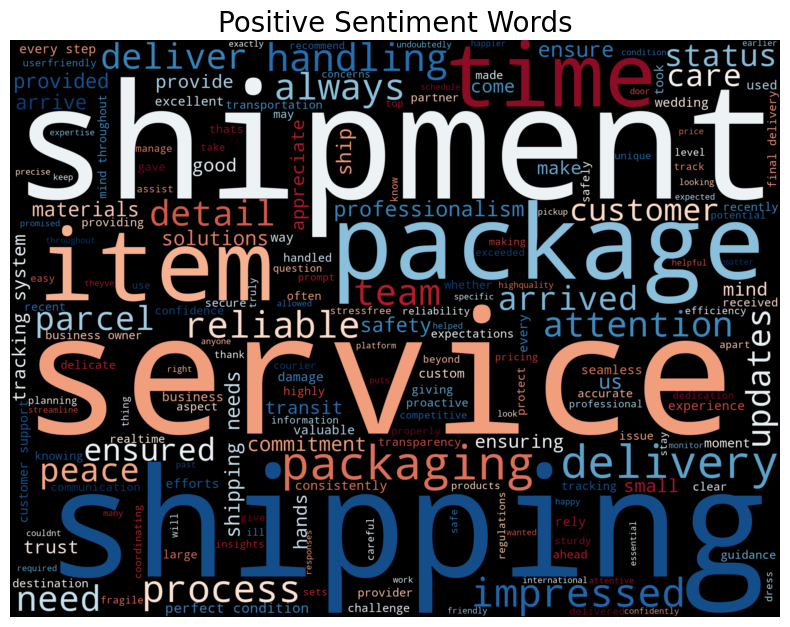


Top 5 Most Frequent Words (excluding stopwords):
shipping: 31
service: 21
delivery: 19
shipment: 17
packaging: 16


In [176]:
# Output a wordcloud for positive sentiment
output_wordcloud(cs_reviews_df, title='Positive Sentiment Words', sentiment='Positive')

#### Observations
- The top words with positive sentiment are shipping, service, delivery, shipment and packaging.
- Other noticable words further down the list include impressed, attention and care all indicating a very positive customer experience.


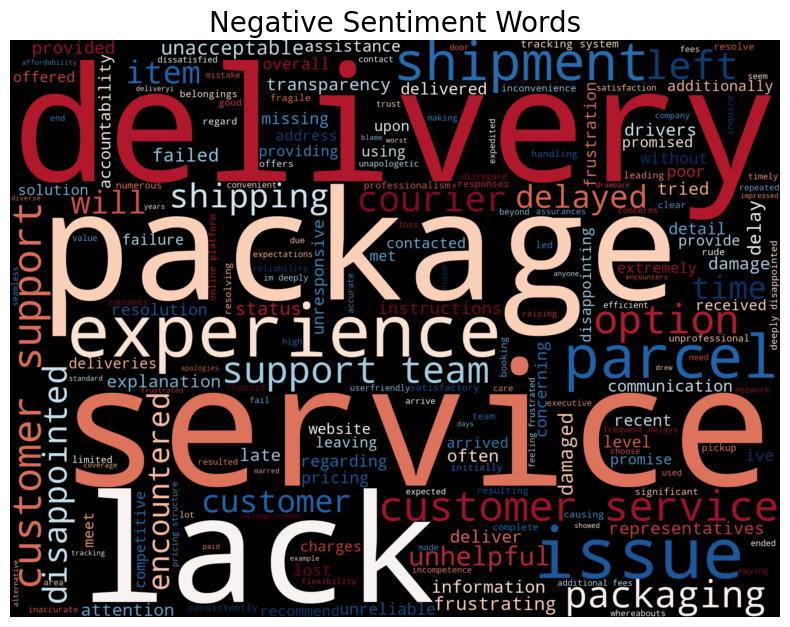


Top 5 Most Frequent Words (excluding stopwords):
service: 36
customer: 35
delivery: 32
lack: 28
package: 20


In [177]:
# Output a wordcloud for negative sentiment
output_wordcloud(cs_reviews_df, title='Negative Sentiment Words', sentiment='Negative')

#### Observations
- The top words with negative sentiment are service, customer, delivery, lack and package.
- Service and delivery appear is both the positive and negative sentiments. 
- Some noticeable words that are prominent in the word cloud are: support, team, disappointed and experience suggesting not only were their delivery issues but the customer experience and support for the customer was unpleasant.

##**Step 3: Derive Prompt (12 Marks)**

(A) Write Zero Shot System Message (3 Marks)

(B) Create Zero Shot Prompt (2 Marks)

(C) Write Few Shot System Message (3 Marks)

(D) Create Examples For Few shot prompte (2 Marks)

(E) Create Few Shot Prompt (2 Marks)

In [178]:
user_message_template = """```{courier_service_review}```"""

**(A) Write Zero Shot System Message (3 Marks)**

In [179]:
# Zero shot system message
basic_system_message = """Classify reviews as Positive or Negative. Reviews will be delimited by triple backticks, that is, ```. Do not return *anything* other than Positive or Negative.
"""
# Prompt with a threshold so that we can control the responses based on a threshold. I took this approach because the dataset does not have probabilistic data simply Positive or Negative. I 
# wanted to use AUC-ROC curves to identify the thresholds but the only approach I was able to find was to use an external source like vaderSentiment or to build a custom model. It seemed much
# more straightforward to leverage the actual prompt and the LLM to optimize the prompt.
probabilistic_system_message = """
You are required to classify the following review using a probability between 0 and 1, where 0 represents extremely Negative sentiment and 1 represents extremely Positive sentiment.

1. First, assign a probability between 0 and 1 to reflect the sentiment of the review.
2. Next, if the assigned probability is greater than {threshold}, return "Positive".
3. If the assigned probability is less than or equal to {threshold}, return "Negative".

Reviews will be delimited by triple backticks, that is, ```.

Under no circumstances should you return any numeric value such as "0" or "1", or any other response besides the exact words "Positive" or "Negative". You must return one of these two words as your final output.
"""


zero_shot_system_message = basic_system_message
zero_shot_probabilistic_system_message = probabilistic_system_message
print("Zero shot system message: {}\n\n".format(zero_shot_system_message))
print("Zero shot probabilistic system message: {}\n".format(zero_shot_probabilistic_system_message))

Zero shot system message: Classify reviews as Positive or Negative. Reviews will be delimited by triple backticks, that is, ```. Do not return *anything* other than Positive or Negative.



Zero shot probabilistic system message: 
You are required to classify the following review using a probability between 0 and 1, where 0 represents extremely Negative sentiment and 1 represents extremely Positive sentiment.

1. First, assign a probability between 0 and 1 to reflect the sentiment of the review.
2. Next, if the assigned probability is greater than {threshold}, return "Positive".
3. If the assigned probability is less than or equal to {threshold}, return "Negative".

Reviews will be delimited by triple backticks, that is, ```.

Under no circumstances should you return any numeric value such as "0" or "1", or any other response besides the exact words "Positive" or "Negative". You must return one of these two words as your final output.




**(B) Create Zero Shot Prompt (2 Marks)**

Zero Shot Non-Probabilistic Prompt

In [180]:
# Zero shot non-probabilistic prompt to be input ready for completion function
zero_shot_prompt = [{'role':'system', 'content': zero_shot_system_message}]

Zero Shot Probabilistic Prompt

In [181]:
# Zero shot probabilistic prompt with a starting threshold of .60
default_threshold = 0.6
zero_shot_probabilistic_prompt = [{'role':'system', 'content': zero_shot_probabilistic_system_message.format(threshold=default_threshold)}]

In [182]:
print("Zero shot non-probabilistic prompt:{}\n\nZero shot probabilistic prompt:{}".format(zero_shot_prompt, zero_shot_probabilistic_prompt))

Zero shot non-probabilistic prompt:[{'role': 'system', 'content': 'Classify reviews as Positive or Negative. Reviews will be delimited by triple backticks, that is, ```. Do not return *anything* other than Positive or Negative.\n'}]

Zero shot probabilistic prompt:[{'role': 'system', 'content': '\nYou are required to classify the following review using a probability between 0 and 1, where 0 represents extremely Negative sentiment and 1 represents extremely Positive sentiment.\n\n1. First, assign a probability between 0 and 1 to reflect the sentiment of the review.\n2. Next, if the assigned probability is greater than 0.6, return "Positive".\n3. If the assigned probability is less than or equal to 0.6, return "Negative".\n\nReviews will be delimited by triple backticks, that is, ```.\n\nUnder no circumstances should you return any numeric value such as "0" or "1", or any other response besides the exact words "Positive" or "Negative". You must return one of these two words as your final

In [183]:
zero_shot_tokens = num_tokens_from_messages(zero_shot_prompt)
zero_shot_probabilistic_tokens = num_tokens_from_messages(zero_shot_probabilistic_prompt)
print("Zero shot non-probabilistic prompt token count:{}\n\nZero shot probabilistic prompt token count:{}".format(zero_shot_tokens, zero_shot_probabilistic_tokens))

Zero shot non-probabilistic prompt token count:41

Zero shot probabilistic prompt token count:163


#### Observations
- The zero_shot_prompt is well-formed and contains the desired content. It has an optimal length of 41 tokens.
- The zero shot probabilistic prompt is well-formed with desired content and has a token length of 163 tokens.

**Let's try our zero-shot prompt on a single example.**

In [184]:
# Pick the first item on the df
input_description = cs_examples_df.iloc[5, 0]

zero_shot_list = [
    {"zero_shot": zero_shot_prompt},
    {"zero_shot_probabilistic": zero_shot_probabilistic_prompt}
]

for item in zero_shot_list:
    for key, prompt in item.items():
        # Get a one time response for this example data item
        response_content = get_chat_response(
            input_description=input_description, 
            chat_model_id=chat_model_id, 
            client=client, 
            prompt_list=prompt,
            user_message_template=user_message_template)

        print("Expected {} response {} predicted response {}".format(key, cs_examples_df.iloc[5,2], response_content))

Expected zero_shot response Negative predicted response Negative
Expected zero_shot_probabilistic response Negative predicted response Negative


#### Observations
- Both the zero shot and zero shot probabilistic prompts predicted Negative correctly.

**(C) Write Few Shot System Message (3 Marks)**

In [185]:
# Few shot system message
few_shot_system_message = basic_system_message

# Probabilistic prompt with default threshold
few_shot_probabilistic_system_message = probabilistic_system_message.format(threshold=default_threshold)

print("Few shot system message: {}\n\n".format(few_shot_system_message))
print("Few shot probabilistic system message: {}\n".format(few_shot_probabilistic_system_message))

Few shot system message: Classify reviews as Positive or Negative. Reviews will be delimited by triple backticks, that is, ```. Do not return *anything* other than Positive or Negative.



Few shot probabilistic system message: 
You are required to classify the following review using a probability between 0 and 1, where 0 represents extremely Negative sentiment and 1 represents extremely Positive sentiment.

1. First, assign a probability between 0 and 1 to reflect the sentiment of the review.
2. Next, if the assigned probability is greater than 0.6, return "Positive".
3. If the assigned probability is less than or equal to 0.6, return "Negative".

Reviews will be delimited by triple backticks, that is, ```.

Under no circumstances should you return any numeric value such as "0" or "1", or any other response besides the exact words "Positive" or "Negative". You must return one of these two words as your final output.




Merely selecting random samples from the polarity subsets is not enough because the examples included in a prompt are prone to a set of known biases such as:
 - Majority label bias (frequent answers in predictions)
 - Recency bias (examples near the end of the prompt)


To avoid these biases, it is important to have a balanced set of examples that are arranged in random order.

**(D) Create Examples For Few shot prompt (2 Marks)**

In [186]:
# Create examples without bias
examples = create_examples(cs_examples_df, 2)

Let's create examples from the stratified dataframe

In [187]:
# Create examples without bias
examples_stratify = create_examples(cs_examples_stratify_df, 2)

In [188]:
# Show the top 5 examples
json.loads(examples)[0:5]

[{'review': 'What impresses me most about ExpressWay Logistics is their commitment to continuous improvement. They are always looking for ways to enhance their services and exceed customer expectations, which is why I continue to choose them for all my shipping needs.',
  'sentiment': 'Positive'},
 {'review': "ExpressWay Logistics promises efficient delivery, but their drivers seem careless and unprofessional. I've received damaged goods more than once, indicating a lack of proper handling procedures.",
  'sentiment': 'Negative'},
 {'review': 'ExpressWay Logistics helped me navigate the customs process for an international shipment, making the process seamless and hassle-free. Their expertise in global logistics was invaluable.',
  'sentiment': 'Positive'},
 {'review': 'I am extremely disappointed with the service provided by ExpressWay Logistics. My parcel was delivered late and damaged, and the customer support team was unhelpful in resolving the issue and closed my support ticket wi

In [189]:
# Show the top 5 examples_stratify 
json.loads(examples_stratify)[0:5]

[{'review': "ExpressWay Logistics' refusal to take responsibility for their mistakes is infuriating. Instead of owning up to errors, they deflect blame onto the customer. It's a shameless display of poor business ethics.",
  'sentiment': 'Negative'},
 {'review': 'Planning a destination wedding is undoubtedly a daunting task, especially when it comes to coordinating transportation for guests and wedding essentials. Fortunately, ExpressWay Logistics made this aspect of our wedding planning effortless. From the beginning, they were attentive to our needs and provided valuable insights to streamline the process.',
  'sentiment': 'Positive'},
 {'review': 'Expressway Logistics is extremely unreliable when it comes to packaging. My recent shipment arrived with items badly damaged due to poor packaging. Despite raising the issue with customer service, there was no satisfactory resolution provided. Their lack of attention to packaging standards is concerning and reflects poorly on their overall

With the non-stratified and stratified examples in place, we can now assemble a few-shot prompt. Since we will be using the few-shot prompt several times during evaluation, let us write a function to create a few-shot prompt (the logic of this function is depicted below).

**(E) Create Few Shot Prompt (2 Marks)**

Few Shot Non-Probabilistic Prompt

In [190]:
few_shot_prompt, few_shot_tokens = create_prompt(
    few_shot_system_message,
    examples,
    user_message_template
)

[{'role': 'system', 'content': 'Classify reviews as Positive or Negative. Reviews will be delimited by triple backticks, that is, ```. Do not return *anything* other than Positive or Negative.\n'}, {'role': 'user', 'content': '```What impresses me most about ExpressWay Logistics is their commitment to continuous improvement. They are always looking for ways to enhance their services and exceed customer expectations, which is why I continue to choose them for all my shipping needs.```'}, {'role': 'assistant', 'content': 'Positive'}, {'role': 'user', 'content': "```ExpressWay Logistics promises efficient delivery, but their drivers seem careless and unprofessional. I've received damaged goods more than once, indicating a lack of proper handling procedures.```"}, {'role': 'assistant', 'content': 'Negative'}, {'role': 'user', 'content': '```ExpressWay Logistics helped me navigate the customs process for an international shipment, making the process seamless and hassle-free. Their expertise

Few Shot Probabilistic Prompt

In [191]:
few_shot_probabilistic_prompt, few_shot_probabilistic_tokens = create_prompt(
    few_shot_probabilistic_system_message,
    examples,
    user_message_template
)

[{'role': 'system', 'content': '\nYou are required to classify the following review using a probability between 0 and 1, where 0 represents extremely Negative sentiment and 1 represents extremely Positive sentiment.\n\n1. First, assign a probability between 0 and 1 to reflect the sentiment of the review.\n2. Next, if the assigned probability is greater than 0.6, return "Positive".\n3. If the assigned probability is less than or equal to 0.6, return "Negative".\n\nReviews will be delimited by triple backticks, that is, ```.\n\nUnder no circumstances should you return any numeric value such as "0" or "1", or any other response besides the exact words "Positive" or "Negative". You must return one of these two words as your final output.\n'}, {'role': 'user', 'content': '```What impresses me most about ExpressWay Logistics is their commitment to continuous improvement. They are always looking for ways to enhance their services and exceed customer expectations, which is why I continue to ch

#### Observations
- The few_shot_prompt is well-formed and contains the desired content. It contains 241 tokens and is much longer than the zero shot and zero shot probabilistic prompts.
- The few_shot_probabilistic_prompt is well-formed and contains the desired content. It contains 363 tokens and is much longer than the zero shot, zero shot probabilistic and the few_shot prompts.

**Let's try our few-shot prompt on a single example.**

In [192]:
# Pick the first item on the df
input_description = cs_examples_df.iloc[5, 0]

zero_shot_list = [
    {"few_shot": few_shot_prompt},
    {"few_shot_probabilistic": few_shot_probabilistic_prompt}
]

for item in zero_shot_list:
    for key, prompt in item.items():
        # Get a one time response for this example data item
        response_content = get_chat_response(
            input_description=input_description, 
            chat_model_id=chat_model_id, 
            client=client, 
            prompt_list=prompt,
            user_message_template=user_message_template)

        print("Expected {} response {} predicted response {}".format(key, cs_examples_df.iloc[5,2], response_content))

Expected few_shot response Negative predicted response Negative
Expected few_shot_probabilistic response Negative predicted response Negative


#### Observations
- Both the few shot and the few shot probabilistic prompts predicted Negative correctly.

##**Step 4: Evaluate prompts (8 Marks)**

- (A) Evaluate Zero Shot Prompt (2 Marks)
    > zero shot non-stratified prompt

    > zero shot probabilistic non-stratified prompt

    > zero shot stratified prompt

    > zero shot probabilistic stratified prompt

- (B) Evaluate Few Shot Prompt (2 marks)
    > few shot prompt
    
    > few shot probabilistic prompt

(C) Calculate Mean and Standard Deviation for Zero Shot Prompt and Few Shot Prompt (4 Marks)

Now we have several sets of prompts that we need to evaluate using gold labels. Since the few-shot prompt depends on the sample of examples that was drawn to make up the prompt, we expect some variability in evaluation. Hence, we evaluate each prompt multiple times to get a sense of the average and the variation around the average.

To reiterate, a choice on the prompt should account for variability due to the choice of the random sample. To aid repeated evaluation, we assemble an evaluation function .

Let us now use this function to do one evaluation of all the two prompts assembled so far, each time computing the Micro-F1 score.

In [193]:
# List of dictionaries store and visualize all the results
evaluation_results = []

**(A) Evaluate zero shot prompt (2 Marks)**

Evaluate zero shot non-stratified prompt

In [194]:
# Evaluate the prompt using the default threshold
f1_score_result, ground_truths, model_predictions = evaluate_prompt(zero_shot_prompt, gold_examples, user_message_template)

In [195]:
print("Micro F1 Score for non-stratified Zero Shot prompt for evaluation run is {}".format(f1_score_result))

# Now lets take a look at the classification report
output_pretty_classification_report(ground_truths, model_predictions, title="Classification Report for non-stratified zero shot prompt")
evaluation_results.append({"key": "non-stratified zero shot prompt", "token_size": zero_shot_tokens, "micro f1-score": f1_score_result})

Micro F1 Score for non-stratified Zero Shot prompt for evaluation run is 0.92


,precision,recall,f1-score,support
Negative,0.86,1.00,0.92,12.00
Positive,1.00,0.85,0.92,13.00
accuracy,0.92,0.92,0.92,0.92
macro avg,0.93,0.92,0.92,25.00
weighted avg,0.93,0.92,0.92,25.00


#### Observations
- The non-stratified zero shot prompt model correctly classified 92% of the reviews as Positive or Negative.
- Negative Reviews:
    > Precision of 86%: Out of all the reviews classified as Negative 86% were actually negative the rest were incorrectly labelled

    > Recall of 100%: The model found all of the actual Negative reviews.

    > F1-score of 92%: The balance between Precision and Recall showing it did a decent job finding Negative reviews.
- Positive Reviews:
   > Precision of 100%: Out of all the reviews classified as Positive 100% were correctly identified as Positive.

    > Recall of 85%: The model correctly identified 85% of the actual Positive reviews but incorrectly labelled the rest as Negative.

    > F1-score of 92%: The balance between Precision and Recall showing it did a decent job finding Positive reviews.

Evaluate zero shot probabilistic non-stratified prompt

In [196]:
# Initialize best values and list to store thresholds with the max F1 score
best_threshold = 0.0
best_f1_score_result = 0.0
best_model_predictions = None
max_f1_thresholds = []

# Evaluate the prompt using a series of thresholds. If we get multiple thresholds with same Micro F1 score take the mean threshold.
for threshold in np.arange(.46, .68, 0.04):
    threshold = round(threshold, 2)
    
    # Generate the current prompt
    current_prompt = [{'role': 'system', 'content': zero_shot_probabilistic_system_message.format(threshold=threshold)}]
    
    # Evaluate the prompt and get F1 score
    f1_score_result, ground_truths, model_predictions = evaluate_prompt(current_prompt, gold_examples, user_message_template)
    
    print(f"Micro F1 Score for non-stratified Zero Shot probabilistic prompt {f1_score_result} threshold={threshold}")
    
    # If a new higher F1 score is found, reset the max_f1_thresholds list
    if f1_score_result > best_f1_score_result:
        best_f1_score_result = f1_score_result
        max_f1_thresholds = [threshold]
        best_model_predictions = model_predictions

    # If the current F1 score matches the best F1 score, add the threshold to the list
    elif f1_score_result == best_f1_score_result:
        max_f1_thresholds.append(threshold)

# Handle cases with multiple thresholds having the same best F1 score either take the mean or the first best.
if len(max_f1_thresholds) > 1:
    # Always choose the mean of the thresholds
    best_threshold = np.mean(max_f1_thresholds)
    
    print(f"Multiple thresholds found with the same F1 score: {max_f1_thresholds}. Using mean threshold: {best_threshold}")
else:
    best_threshold = max_f1_thresholds[0]

# Final output with the best threshold
f1_score_result = best_f1_score_result
model_predictions = best_model_predictions
evaluation_results.append({"key": "non-stratified zero shot probabilistic prompt", "token_size": zero_shot_probabilistic_tokens, 
                            "micro f1-score": f1_score_result
})

zero_shot_probabilistic_system_message = zero_shot_probabilistic_system_message.format(threshold=best_threshold)

Micro F1 Score for non-stratified Zero Shot probabilistic prompt 0.88 threshold=0.46
Micro F1 Score for non-stratified Zero Shot probabilistic prompt 0.92 threshold=0.5
Micro F1 Score for non-stratified Zero Shot probabilistic prompt 0.92 threshold=0.54
Micro F1 Score for non-stratified Zero Shot probabilistic prompt 0.92 threshold=0.58
Micro F1 Score for non-stratified Zero Shot probabilistic prompt 0.96 threshold=0.62
Micro F1 Score for non-stratified Zero Shot probabilistic prompt 0.96 threshold=0.66
Multiple thresholds found with the same F1 score: [0.62, 0.66]. Using mean threshold: 0.64


In [197]:
print("Micro F1 Score for non-stratified Zero Shot probabilistic prompy for evaluation run is {} optimal threshold is {}".format(f1_score_result, best_threshold))

# Now lets take a look at the classification report
output_pretty_classification_report(ground_truths, model_predictions, title="Classification Report for non-stratified zero shot probabilistic prompt")

Micro F1 Score for non-stratified Zero Shot probabilistic prompy for evaluation run is 0.96 optimal threshold is 0.64


,precision,recall,f1-score,support
Negative,0.92,1.00,0.96,12.00
Positive,1.00,0.92,0.96,13.00
accuracy,0.96,0.96,0.96,0.96
macro avg,0.96,0.96,0.96,25.00
weighted avg,0.96,0.96,0.96,25.00


#### Observations
- The non-stratified zero shot probabilistic prompt model correctly classified 96% of the reviews as Positive or Negative.
- We found an optimal threshold of .64 to embed in the prompt to reach this accuracy.
- The class distribution is relatively balanced (51.9% Positive, 48% Negative), which is generally good for classification tasks as it reduces the risk of class imbalance issues. The threshold value of 0.64 indicates that reviews might lean more toward a neutral sentiment, requiring a higher probability threshold to confidently classify a review as Positive. In addition, the higher threshold may indicate that the reviews are often nuanced or contain mixed sentiments, requiring a more conservative decision-making process for Positive classifications. 

- Negative Reviews:
    > Precision of 92%: Out of all the reviews classified as Negative 92% were actually negative the rest were incorrectly labelled

    > Recall of 100%: The model found all of the actual Negative reviews.

    > F1-score of 96%: The balance between Precision and Recall showing it did a excellent job finding Negative reviews.
- Positive Reviews:
   > Precision of 100%: Out of all the reviews classified as Positive 100% were correctly identified as Positive.

    > Recall of 92%: The model correctly identified 92% of the actual Positive reviews but incorrectly labelled the rest as Negative.

    > F1-score of 96%: The balance between Precision and Recall showing it did a excellent job finding Positive reviews.

Evaluate zero shot stratified prompt

In [198]:
# Lets' evalaute the zero shot with stratified data
f1_score_result, ground_truths, model_predictions = evaluate_prompt(zero_shot_prompt, gold_examples_stratify, user_message_template)
evaluation_results.append({"key": "stratified zero shot prompt", "token_size": zero_shot_tokens, "micro f1-score": f1_score_result})

In [199]:
print("Micro F1 Score for stratified Zero Shot prompt for evaluation run is {}".format(f1_score_result))

# Now lets take a look at the classification report
output_pretty_classification_report(ground_truths, model_predictions, title="Classification Report for stratified zero shot prompt")

Micro F1 Score for stratified Zero Shot prompt for evaluation run is 1.0


,precision,recall,f1-score,support
Negative,1.00,1.00,1.00,13.00
Positive,1.00,1.00,1.00,12.00
accuracy,1.00,1.00,1.00,1.00
macro avg,1.00,1.00,1.00,25.00
weighted avg,1.00,1.00,1.00,25.00


#### Observations
- The stratified zero shot prompt model correctly classified 100% of the reviews as Positive or Negative.
- This is somewhat concerning because its very likely the model overfit the data. There are likely a few reasons. First the dataset is very small and second the examples provided in the dataset are likely somewhat simplistic.
- Negative Reviews:
    > Precision of 100%: Out of all the reviews classified as Negative 100% were actually negative.

    > Recall of 100%: The model found all of the actual Negative reviews.

    > F1-score of 100%: The balance between Precision and Recall showing it did a excellent job finding Negative reviews.
- Positive Reviews:
   > Precision of 100%: Out of all the reviews classified as Positive 100% were correctly identified as Positive.

    > Recall of 100%: The model correctly identified 100% of the actual Positive reviews.

    > F1-score of 100%: The balance between Precision and Recall showing it did a excellent job finding Positive reviews.

Evaluate zero shot probabilistic stratified prompt

In [200]:
# Lets' evalaute the zero probabilistic shot with stratified data
f1_score_result, ground_truths, model_predictions = evaluate_prompt(zero_shot_probabilistic_prompt, gold_examples_stratify, user_message_template)
evaluation_results.append({"key": "stratified zero shot probabilistic prompt", "token_size": zero_shot_probabilistic_tokens, "micro f1-score": f1_score_result})

In [201]:
# Now lets take a look at the classification report
print("Micro F1 Score for stratified Zero Shot probabilistic_prompt for evaluation run is {}".format(f1_score_result))
output_pretty_classification_report(ground_truths, model_predictions, title="Classification Report for stratified zero shot probabilistic prompt")

Micro F1 Score for stratified Zero Shot probabilistic_prompt for evaluation run is 1.0


,precision,recall,f1-score,support
Negative,1.00,1.00,1.00,13.00
Positive,1.00,1.00,1.00,12.00
accuracy,1.00,1.00,1.00,1.00
macro avg,1.00,1.00,1.00,25.00
weighted avg,1.00,1.00,1.00,25.00


#### Observations
- The stratified zero shot probabilistic prompt model correctly classified 100% of the reviews as Positive or Negative.
- This is somewhat concerning because its very likely the model overfit the data. There are likely a few reasons. First the dataset is very small and second the examples provided in the dataset are likely somewhat simplistic.
- Negative Reviews:
    > Precision of 100%: Out of all the reviews classified as Negative 100% were actually negative.

    > Recall of 100%: The model found all of the actual Negative reviews.

    > F1-score of 100%: The balance between Precision and Recall showing it did a excellent job finding Negative reviews.
- Positive Reviews:
   > Precision of 100%: Out of all the reviews classified as Positive 100% were correctly identified as Positive.

    > Recall of 100%: The model correctly identified 100% of the actual Positive reviews.

    > F1-score of 100%: The balance between Precision and Recall showing it did a excellent job finding Positive reviews.

**There is no need to carry forward the stratification experimentation since it appears the zero shot models are overfit and given the few shot models provide additional content it is unlikely the results won't be overfit.**

**(B) Evaluate few shot prompt (2 Marks)**

Evaluate Few Shot Non-Probabilistic prompt

In [202]:
f1_score_result, ground_truths, model_predictions = evaluate_prompt(few_shot_prompt, gold_examples, user_message_template)
evaluation_results.append({"key": "few shot prompt", "token_size": few_shot_tokens, "micro f1-score": f1_score_result})

In [203]:
print("Micro F1 Score for Few Shot for evaluation run is {}".format(f1_score_result))

# Now lets take a look at the classification report
output_pretty_classification_report(ground_truths, model_predictions, title="Classification Report for non-stratified few shot prompt")

Micro F1 Score for Few Shot for evaluation run is 0.92


,precision,recall,f1-score,support
Negative,0.86,1.00,0.92,12.00
Positive,1.00,0.85,0.92,13.00
accuracy,0.92,0.92,0.92,0.92
macro avg,0.93,0.92,0.92,25.00
weighted avg,0.93,0.92,0.92,25.00


#### Observations
- The few shot prompt model correctly classified 92% of the reviews as Positive or Negative.
- Negative Reviews:
    > Precision of 86%: Out of all the reviews classified as Negative 86% were actually negative the rest were incorrectly labelled

    > Recall of 100%: The model found all of the actual Negative reviews.

    > F1-score of 92%: The balance between Precision and Recall showing it did a decent job finding Negative reviews.
- Positive Reviews:
   > Precision of 100%: Out of all the reviews classified as Positive 100% were correctly identified as Positive.

    > Recall of 85%: The model correctly identified 85% of the actual Positive reviews but incorrectly labelled the rest as Negative.

    > F1-score of 92%: The balance between Precision and Recall showing it did a decent job finding Positive reviews.

Evaluate Few Shot Probabilistic prompt

In [204]:
# If we found a different threshold for the zero shot probabilistic prompt from the default let's use it.
if best_threshold != default_threshold:
    few_shot_probabilistic_system_message = probabilistic_system_message.format(threshold=best_threshold)
    few_shot_probabilistic_prompt, few_shot_probabilistic_tokens = create_prompt(few_shot_probabilistic_system_message,
                                                examples, user_message_template)

[{'role': 'system', 'content': '\nYou are required to classify the following review using a probability between 0 and 1, where 0 represents extremely Negative sentiment and 1 represents extremely Positive sentiment.\n\n1. First, assign a probability between 0 and 1 to reflect the sentiment of the review.\n2. Next, if the assigned probability is greater than 0.64, return "Positive".\n3. If the assigned probability is less than or equal to 0.64, return "Negative".\n\nReviews will be delimited by triple backticks, that is, ```.\n\nUnder no circumstances should you return any numeric value such as "0" or "1", or any other response besides the exact words "Positive" or "Negative". You must return one of these two words as your final output.\n'}, {'role': 'user', 'content': '```What impresses me most about ExpressWay Logistics is their commitment to continuous improvement. They are always looking for ways to enhance their services and exceed customer expectations, which is why I continue to 

In [205]:
f1_score_result, ground_truths, model_predictions = evaluate_prompt(few_shot_probabilistic_prompt, gold_examples, user_message_template)
evaluation_results.append({"key": "few shot probabilistic prompt", "token_size": few_shot_probabilistic_tokens, "micro f1-score": f1_score_result})

In [206]:
print("Micro F1 Score for non-stratified Few Shot probabilistic prompt for evaluation run is {}".format(f1_score_result))

# Now lets take a look at the classification report
output_pretty_classification_report(ground_truths, model_predictions, title="Classification Report for non-stratified few shot probabilistic prompt")

Micro F1 Score for non-stratified Few Shot probabilistic prompt for evaluation run is 0.92


,precision,recall,f1-score,support
Negative,0.86,1.00,0.92,12.00
Positive,1.00,0.85,0.92,13.00
accuracy,0.92,0.92,0.92,0.92
macro avg,0.93,0.92,0.92,25.00
weighted avg,0.93,0.92,0.92,25.00


#### Observations
- The few shot probabilistic prompt model correctly classified 92% of the reviews as Positive or Negative.
- Negative Reviews:
    > Precision of 86%: Out of all the reviews classified as Negative 86% were actually negative the rest were incorrectly labelled

    > Recall of 100%: The model found all of the actual Negative reviews.

    > F1-score of 92%: The balance between Precision and Recall showing it did a decent job finding Negative reviews.
- Positive Reviews:
   > Precision of 100%: Out of all the reviews classified as Positive 100% were correctly identified as Positive.

    > Recall of 85%: The model correctly identified 85% of the actual Positive reviews but incorrectly labelled the rest as Negative.

    > F1-score of 92%: The balance between Precision and Recall showing it did a decent job finding Positive reviews.

**Single Run Model Results**

In [207]:
evaluation_df = pd.DataFrame(evaluation_results)
display(evaluation_df)

,key,token_size,micro f1-score
0,non-stratified zero shot prompt,41,0.92
1,non-stratified zero shot probabilistic prompt,163,0.96
2,stratified zero shot prompt,41,1.00
3,stratified zero shot probabilistic prompt,163,1.00
4,few shot prompt,241,0.92
5,few shot probabilistic prompt,363,0.92


#### Observations
- Based on the single run results the non-stratified zero shot probabilistic prompt exhibited the highest Micro F1 score.
- The non-stratified zero shot probabilistic prompt has a token size about four times the size of non-stratified zero shot prompt but showed a 4% Micro F1 increase.
- The few shot prompts although having more context with embedded examples did not show an improvement over the smaller non-stratified zero shot prompt.
- The stratified prompts as mentioned earlier are both likely examples of overfitting.

However, this is just *one* choice of examples. We will need to run these evaluations with multiple choices of examples to get a sense of variability in F1 score for the few-shot prompt. As an example, let us run evaluations for the few-shot prompt 5 times.

In [208]:
# Perform multiple runs on the non-stratified prompts
zero_shot_performance, few_shot_performance = run_multiple_evaluations(cs_examples_df, zero_shot_system_message, few_shot_system_message, 
                                                                        gold_examples, user_message_template)

  0%|          | 0/5 [00:00<?, ?it/s]

,precision,recall,f1-score,support
Negative,0.86,1.00,0.92,12.00
Positive,1.00,0.85,0.92,13.00
accuracy,0.92,0.92,0.92,0.92
macro avg,0.93,0.92,0.92,25.00
weighted avg,0.93,0.92,0.92,25.00


[{'role': 'system', 'content': 'Classify reviews as Positive or Negative. Reviews will be delimited by triple backticks, that is, ```. Do not return *anything* other than Positive or Negative.\n'}, {'role': 'user', 'content': '```Although ExpressWay Logistics boasts about their extensive network, the reality is their tracking system is unreliable. Packages often go missing without any explanation or compensation for the inconvenience caused.```'}, {'role': 'assistant', 'content': 'Negative'}, {'role': 'user', 'content': "```At first, I was impressed by the speed and efficiency of ExpressWay Logistics' delivery service. However, upon closer inspection, I noticed that the packaging was slightly damaged and the items inside were okay . Despite their claims of reliability, I found their customer support to be responsive but unhelpful when I tried to resolve the issue. Overall, my experience with ExpressWay Logistics was not so bad!```"}, {'role': 'assistant', 'content': 'Positive'}, {'role

,precision,recall,f1-score,support
Negative,0.86,1.00,0.92,12.00
Positive,1.00,0.85,0.92,13.00
accuracy,0.92,0.92,0.92,0.92
macro avg,0.93,0.92,0.92,25.00
weighted avg,0.93,0.92,0.92,25.00


 20%|██        | 1/5 [05:05<20:23, 305.83s/it]

...

 80%|████████  | 4/5 [19:18<04:51, 291.72s/it]

,precision,recall,f1-score,support
Negative,0.86,1.00,0.92,12.00
Positive,1.00,0.85,0.92,13.00
accuracy,0.92,0.92,0.92,0.92
macro avg,0.93,0.92,0.92,25.00
weighted avg,0.93,0.92,0.92,25.00


[{'role': 'system', 'content': 'Classify reviews as Positive or Negative. Reviews will be delimited by triple backticks, that is, ```. Do not return *anything* other than Positive or Negative.\n'}, {'role': 'user', 'content': "```I had a large, bulky item to ship, and I wasn't sure if it would fit in a standard package. ExpressWay Logistics offered customized packaging solutions and delivered the item without any issues.```"}, {'role': 'assistant', 'content': 'Positive'}, {'role': 'user', 'content': "```I recently used ExpressWay Logistics to ship some fragile items, and I couldn't be happier with the service. They took great care in packaging my items, and everything arrived intact. I'll definitely be recommending them to friends and family!```"}, {'role': 'assistant', 'content': 'Positive'}, {'role': 'user', 'content': "```I had a frustrating experience with ExpressWay Logistics' online tracking system, which provided inaccurate and misleading information about the status of my shipm

,precision,recall,f1-score,support
Negative,0.86,1.00,0.92,12.00
Positive,1.00,0.85,0.92,13.00
accuracy,0.92,0.92,0.92,0.92
macro avg,0.93,0.92,0.92,25.00
weighted avg,0.93,0.92,0.92,25.00


100%|██████████| 5/5 [24:28<00:00, 293.64s/it]


In [209]:
# Perform multiple runs for the zero shot stratified prompts
zero_shot_stratified_performance, _ = run_multiple_evaluations(cs_examples_df, zero_shot_system_message, None,
                                                                        gold_examples_stratify, user_message_template)

  0%|          | 0/5 [00:00<?, ?it/s]

,precision,recall,f1-score,support
Negative,1.00,1.00,1.00,13.00
Positive,1.00,1.00,1.00,12.00
accuracy,1.00,1.00,1.00,1.00
macro avg,1.00,1.00,1.00,25.00
weighted avg,1.00,1.00,1.00,25.00


 20%|██        | 1/5 [00:56<03:45, 56.41s/it]

,precision,recall,f1-score,support
Negative,1.00,1.00,1.00,13.00
Positive,1.00,1.00,1.00,12.00
accuracy,1.00,1.00,1.00,1.00
macro avg,1.00,1.00,1.00,25.00
weighted avg,1.00,1.00,1.00,25.00


 40%|████      | 2/5 [01:04<01:23, 27.72s/it]

...

 60%|██████    | 3/5 [01:59<01:20, 40.34s/it]

,precision,recall,f1-score,support
Negative,1.00,1.00,1.00,13.00
Positive,1.00,1.00,1.00,12.00
accuracy,1.00,1.00,1.00,1.00
macro avg,1.00,1.00,1.00,25.00
weighted avg,1.00,1.00,1.00,25.00


 80%|████████  | 4/5 [02:06<00:27, 27.30s/it]

,precision,recall,f1-score,support
Negative,1.00,1.00,1.00,13.00
Positive,1.00,1.00,1.00,12.00
accuracy,1.00,1.00,1.00,1.00
macro avg,1.00,1.00,1.00,25.00
weighted avg,1.00,1.00,1.00,25.00


100%|██████████| 5/5 [03:03<00:00, 36.67s/it]


In [210]:
# Perform multiple runs for the zero shot probabilstic stratified prompts
zero_shot_probabilistic_stratified_performance, _ = run_multiple_evaluations(cs_examples_df, zero_shot_probabilistic_system_message, None,
                                                                        gold_examples_stratify, user_message_template)

  0%|          | 0/5 [00:00<?, ?it/s]

,precision,recall,f1-score,support
Negative,1.00,1.00,1.00,13.00
Positive,1.00,1.00,1.00,12.00
accuracy,1.00,1.00,1.00,1.00
macro avg,1.00,1.00,1.00,25.00
weighted avg,1.00,1.00,1.00,25.00


 20%|██        | 1/5 [01:04<04:16, 64.24s/it]

,precision,recall,f1-score,support
Negative,1.00,1.00,1.00,13.00
Positive,1.00,1.00,1.00,12.00
accuracy,1.00,1.00,1.00,1.00
macro avg,1.00,1.00,1.00,25.00
weighted avg,1.00,1.00,1.00,25.00


 40%|████      | 2/5 [02:57<04:39, 93.15s/it]

...

 60%|██████    | 3/5 [04:02<02:40, 80.21s/it]

,precision,recall,f1-score,support
Negative,1.00,1.00,1.00,13.00
Positive,1.00,1.00,1.00,12.00
accuracy,1.00,1.00,1.00,1.00
macro avg,1.00,1.00,1.00,25.00
weighted avg,1.00,1.00,1.00,25.00


 80%|████████  | 4/5 [05:05<01:13, 73.37s/it]

,precision,recall,f1-score,support
Negative,1.00,1.00,1.00,13.00
Positive,1.00,1.00,1.00,12.00
accuracy,1.00,1.00,1.00,1.00
macro avg,1.00,1.00,1.00,25.00
weighted avg,1.00,1.00,1.00,25.00


100%|██████████| 5/5 [06:59<00:00, 83.93s/it]


In [211]:
# Perform multiple runs on the probabilistic prompts
zero_shot_probabilistic_performance, few_shot_probabilistic_performance = run_multiple_evaluations(cs_examples_df, zero_shot_probabilistic_system_message, 
                                                                                                   few_shot_probabilistic_system_message, 
                                                                                                   gold_examples, user_message_template)

  0%|          | 0/5 [00:00<?, ?it/s]

,precision,recall,f1-score,support
Negative,0.92,1.00,0.96,12.00
Positive,1.00,0.92,0.96,13.00
accuracy,0.96,0.96,0.96,0.96
macro avg,0.96,0.96,0.96,25.00
weighted avg,0.96,0.96,0.96,25.00


[{'role': 'system', 'content': '\nYou are required to classify the following review using a probability between 0 and 1, where 0 represents extremely Negative sentiment and 1 represents extremely Positive sentiment.\n\n1. First, assign a probability between 0 and 1 to reflect the sentiment of the review.\n2. Next, if the assigned probability is greater than 0.64, return "Positive".\n3. If the assigned probability is less than or equal to 0.64, return "Negative".\n\nReviews will be delimited by triple backticks, that is, ```.\n\nUnder no circumstances should you return any numeric value such as "0" or "1", or any other response besides the exact words "Positive" or "Negative". You must return one of these two words as your final output.\n'}, {'role': 'user', 'content': '```Expressway Logistics is a textbook example of how not to run a courier service. They lost my package not once, but twice, and each time they offered empty apologies with no real solutions. Their lack of accountability

,precision,recall,f1-score,support
Negative,0.86,1.00,0.92,12.00
Positive,1.00,0.85,0.92,13.00
accuracy,0.92,0.92,0.92,0.92
macro avg,0.93,0.92,0.92,25.00
weighted avg,0.93,0.92,0.92,25.00


 20%|██        | 1/5 [06:07<24:28, 367.07s/it]

...

 80%|████████  | 4/5 [25:22<06:21, 381.90s/it]

,precision,recall,f1-score,support
Negative,0.92,1.00,0.96,12.00
Positive,1.00,0.92,0.96,13.00
accuracy,0.96,0.96,0.96,0.96
macro avg,0.96,0.96,0.96,25.00
weighted avg,0.96,0.96,0.96,25.00


[{'role': 'system', 'content': '\nYou are required to classify the following review using a probability between 0 and 1, where 0 represents extremely Negative sentiment and 1 represents extremely Positive sentiment.\n\n1. First, assign a probability between 0 and 1 to reflect the sentiment of the review.\n2. Next, if the assigned probability is greater than 0.64, return "Positive".\n3. If the assigned probability is less than or equal to 0.64, return "Negative".\n\nReviews will be delimited by triple backticks, that is, ```.\n\nUnder no circumstances should you return any numeric value such as "0" or "1", or any other response besides the exact words "Positive" or "Negative". You must return one of these two words as your final output.\n'}, {'role': 'user', 'content': '```My interactions with ExpressWay Logistics have been marred by inconsistency and frustration. While their user-friendly website and diverse shipping options initially drew me in, the frequent delays in delivery have be

,precision,recall,f1-score,support
Negative,0.86,1.00,0.92,12.00
Positive,1.00,0.85,0.92,13.00
accuracy,0.92,0.92,0.92,0.92
macro avg,0.93,0.92,0.92,25.00
weighted avg,0.93,0.92,0.92,25.00


100%|██████████| 5/5 [31:30<00:00, 378.09s/it]


In [212]:
(zero_shot_performance, few_shot_performance)

([0.92, 0.92, 0.92, 0.92, 0.92], [0.92, 0.92, 0.92, 0.92, 0.92])

In [213]:
zero_shot_stratified_performance

[1.0, 1.0, 1.0, 1.0, 1.0]

In [214]:
zero_shot_probabilistic_stratified_performance

[1.0, 1.0, 1.0, 1.0, 1.0]

In [215]:
(zero_shot_probabilistic_performance, few_shot_probabilistic_performance)

([0.96, 0.96, 0.96, 0.92, 0.96], [0.92, 0.92, 0.92, 0.92, 0.92])

**(C) Calculate Mean and Standard Deviation for Zero Shot Prompt and Few Shot Prompt (4 Marks)**

Compute the average (mean) and measure the variability (standard deviation) of the evaluation scores for both zero shot and few shot prompts.

In [216]:
# Dictionaries to capture mean and stddev results that will be mapped to the evaluation dataframe
mean_dict = {}
stddev_dict = {}

In [217]:
mean, stdev = calculate_mean_and_stdev(zero_shot_performance)
mean_dict['non-stratified zero shot prompt'] = mean
stddev_dict['non-stratified zero shot prompt'] = stdev

print(f"Zero Shot Micro F1 Score Mean: {mean}, Standard Deviation: {stdev}")

Zero Shot Micro F1 Score Mean: 0.9200000000000002, Standard Deviation: 1.1102230246251565e-16


In [218]:
mean, stdev = calculate_mean_and_stdev(zero_shot_stratified_performance)
mean_dict['stratified zero shot prompt'] = mean
stddev_dict['stratified zero shot prompt'] = stdev

print(f"Zero Shot statified Micro F1 Score Mean: {mean}, Standard Deviation: {stdev}")

Zero Shot statified Micro F1 Score Mean: 1.0, Standard Deviation: 0.0


In [219]:
mean, stdev = calculate_mean_and_stdev(few_shot_performance)
mean_dict['few shot prompt'] = mean
stddev_dict['few shot prompt'] = stdev

print(f"Few Shot Micro F1 Score Mean: {mean}, Standard Deviation: {stdev}")

Few Shot Micro F1 Score Mean: 0.9200000000000002, Standard Deviation: 1.1102230246251565e-16


In [220]:
mean, stdev = calculate_mean_and_stdev(zero_shot_probabilistic_performance)
mean_dict['non-stratified zero shot probabilistic prompt'] = mean
stddev_dict['non-stratified zero shot probabilistic prompt'] = stdev

print(f"Zero Shot Probabilistic Micro F1 Score Mean: {mean}, Standard Deviation: {stdev}")

Zero Shot Probabilistic Micro F1 Score Mean: 0.952, Standard Deviation: 0.01599999999999997


In [221]:
mean, stdev = calculate_mean_and_stdev(zero_shot_probabilistic_stratified_performance)
mean_dict['stratified zero shot probabilistic prompt'] = mean
stddev_dict['stratified zero shot probabilistic prompt'] = stdev

print(f"Zero Shot stratified Probabilistic Micro F1 Score Mean: {mean}, Standard Deviation: {stdev}")

Zero Shot stratified Probabilistic Micro F1 Score Mean: 1.0, Standard Deviation: 0.0


In [222]:
mean, stdev = calculate_mean_and_stdev(few_shot_probabilistic_performance)
mean_dict['few shot probabilistic prompt'] = mean
stddev_dict['few shot probabilistic prompt'] = stdev

print(f"Few Shot Probabilistic Micro F1 Score Mean: {mean}, Standard Deviation: {stdev}")

Few Shot Probabilistic Micro F1 Score Mean: 0.9200000000000002, Standard Deviation: 1.1102230246251565e-16


### Final Results

In [223]:
# Roll up all the mean and stddev result into the evaluation dataframe
evaluation_df['mean'] = evaluation_df['key'].map(mean_dict)
evaluation_df['stddev'] = evaluation_df['key'].map(stddev_dict)
display(evaluation_df)

,key,token_size,micro f1-score,mean,stddev
0,non-stratified zero shot prompt,41,0.92,0.920,1.110223e-16
1,non-stratified zero shot probabilistic prompt,163,0.96,0.952,1.600000e-02
2,stratified zero shot prompt,41,1.00,1.000,0.000000e+00
3,stratified zero shot probabilistic prompt,163,1.00,1.000,0.000000e+00
4,few shot prompt,241,0.92,0.920,1.110223e-16
5,few shot probabilistic prompt,363,0.92,0.920,1.110223e-16


#### Observations
- Based on the multi-run results the non-stratified zero shot probabilistic prompt exhibited the highest mean Micro F1 score of .952 with minimal variability. A small standard deviation menas that the model is consistenly achieving results that are close the mean (for the five runs)
- The non-stratified zero shot prompt maintained a Micro F1 score of .92 with minimal variability. A small standard deviation menas that the model is consistenly achieving results that are close the mean (for the five runs)
- The few shot prompts maintained a Micro F1 score of .92 with minimal variability. A small standard deviation menas that the model is consistenly achieving results that are close the mean (for the five runs)
- The stratified prompts continued to show a Micro F1 score of 1.0 with minimal variability despite changes in examples injected into the prompt.
- Comparined the zero shot and few shot prompts we learned that the additional examples injected in the few shot prompts did not offer additional context to better help distinguish classes.
- The chosen prompt based on performance and stability is non-stratified zero shot probabilistic prompt.

## Qualitative Analysis

I thought it would be useful to do a qualitative analysis on the actual reviews to extract themes along with strengths and weaknesses of ExpressWay Logistics. The key objective here is to identify areas where the company can take immediate action or continue to grow an existing strength.

I started out with a prompt I fed to my ChatGPT 4o (I have a subscription to api and chatbot) and got excellent results:


```python
Act as a customer support expert in the logistics industry, specifically focusing on delivery services, packaging, and customer service. Evaluate the attached CSV file, which contains a column titled "review".

Your task is to identify and categorize common strengths and weaknesses from these reviews across the following key areas:

Operational Efficiency: This refers to the speed and accuracy of deliveries, handling of logistics operations, and any delays or errors.
Customer Satisfaction: This refers to overall customer feedback on communication, professionalism, and satisfaction with the service.
Durable Packaging: This refers to the quality and durability of packaging materials and whether items arrived undamaged.
On-time Delivery: This refers to how consistently deliveries arrive within the promised time frame.
For each category, organize the output into the following format:

Operational Efficiency

Strengths:
<identified strength>
…
Weaknesses:
<identified weakness>
…
Customer Satisfaction

Strengths:
<identified strength>
…
Weaknesses:
<identified weakness>
…
Durable Packaging

Strengths:
<identified strength>
…
Weaknesses:
<identified weakness>
…
On-time Delivery

Strengths:
<identified strength>
...
Weaknesses:
<identified weakness>
…

If no strengths or weaknesses are found in a category, simply state None Found!
```

I converted to prompt to run in the notebook. Unfortunately with the GL AzureOpenAI subscription it hit my rate limit. The code is below:

```python
def send_reviews_to_azure_openai(reviews_df):

    prompt = """
    I want you to act as a customer support expert in the logistics industry, focusing on delivery services, packaging, and customer service.
    Evaluate the reviews below and categorize common strengths and weaknesses across the following key areas:

    Operational Efficiency: Speed and accuracy of deliveries, handling logistics operations, and any delays or errors.
    Customer Satisfaction: Overall feedback on communication, professionalism, and satisfaction with the service.
    Durable Packaging: The quality and durability of packaging materials, whether items arrived undamaged.
    On-time Delivery: How consistently deliveries arrive within the promised time frame.

    For each category, organize the output into the following format:
    
    Operational Efficiency:
    Strengths:
    <identified strengths>...
    Weaknesses:
    <identified weaknesses>...
    
    Customer Satisfaction:
    Strengths:
    <identified strengths>...
    Weaknesses:
    <identified weaknesses>...
    
    Durable Packaging:
    Strengths:
    <identified strengths>...
    Weaknesses:
    <identified weaknesses>...
    
    On-time Delivery:
    Strengths:
    <identified strengths>...
    Weaknesses:
    <identified weaknesses>...
    
    Reviews:
    `{reviews}`
    """

    reviews_text = "\n".join(reviews_df['review'])
    prompt_filled = prompt.replace("{reviews}", reviews_text)

    # Make the API call to Azure OpenAI
    response = openai.ChatCompletion.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt_filled}
        ],
        temperature=0,
        max_tokens=1500  # Adjust tokens as needed based on the response length
    )
    
    # Get the response text
    output = response['choices'][0]['message']['content']
    return output
```

**Since I can't run this in the current GL provided environment I ran it separately and pasted the results below.**

#### Operational Efficiency
##### Strengths:

- "ExpressWay Logistics' commitment to transparency in their logistics operations is truly commendable. Every step is clear and easy to follow."
- "ExpressWay Logistics is known for ensuring logistics run smoothly with excellent operational efficiency."
##### Weaknesses:

- "ExpressWay Logistics failed to meet my expectations with numerous operational errors and delays."
- "The tracking system was inconsistent, causing confusion and delays in receiving my packages."
#### Customer Satisfaction
##### Strengths:

- "The professionalism and customer service I received from ExpressWay Logistics have been top-notch."
- "Their transparent communication made the whole process easy, and I felt valued as a customer."
##### Weaknesses:

- "Customer service was unhelpful, and I encountered multiple issues with poor communication."
- "I had a terrible experience with customer support, and they didn’t provide the assistance I needed."
#### Durable Packaging
##### Strengths:

- "The packaging provided by ExpressWay Logistics was sturdy, and my items arrived in perfect condition."
- "I was impressed with the quality of the packaging material used for my shipment."
##### Weaknesses:

- "The packaging was damaged, resulting in loss of items."
- "Poor packaging quality led to damaged goods upon arrival."
#### On-time Delivery
##### Strengths:

- "ExpressWay Logistics' prompt and professional service ensures that my packages always arrive on time."
- "They are known for their reliability and delivering packages ahead of schedule."
#### Weaknesses:

- "My parcel was delivered late without explanation."
- "Repeated delays in delivery have made me question their reliability."

##**Step 5: Observation and Insights and Business perspective (3 Marks)**
### Actionable Insights and Recommendations
* The chosen prompt based on performance and stability is non-stratified zero shot probabilistic prompt. It delivers a .952 Micro F1 score which will allow ExpressWay Logistics to proactively identify and corrrect problems in the key areas of: Operational Efficiency, Customer Service, Package Quality and On-Time Delivery.
    > The threshold value for zero shot probabilistic prompt of 0.64 indicates that the current reviews might lean more toward a neutral sentiment, requiring a higher probability threshold to confidently classify a review as Positive. In addition, the higher threshold may indicate that the reviews are often nuanced or contain mixed sentiments, requiring a more conservative decision-making process for Positive classifications. This threshold should be monitored as additional reviews are added to the dataset.

    > If cost becomes an issue based on token size the non-stratified zero shot prompt is an alternative offers a Micro F1 score of .92 and is about a quarter of the non-stratified zero shot probabilistic prompt size.
    
    > The prompt model can be enhanced to output a percentage and a category for the review so that responses can be prioritized by KPI.


* Key themes derived from the reviews tie directly to the objective in this project. I strongly recommend that metrics are established for the KPI's of Operational Efficiency, Customer Service, Package Quality and On-Time Delivery. These metrics should be clear, measurable, monitored, acted upon and always viewable by employees. 
* Employing either the stratified or non-stratified zero shot model (both with high Micro F1 scores) will allow ExpressWay Logistics to proactively determine which KPI's need to be addressed in order to solve issues and mitigate any customer dissatisfaction.
* Enhance Operational Efficiency: Address delays in logistics operations and inconsistencies in the tracking system. Implement stricter quality checks to ensure smooth deliveries.
    > If reviews highlight dissatisfaction in operational efficiency ask for immediate customer feedback to get details, identify operational efficiency goals on a quarterly basis and monitor these goals and conducts frequent audits of these goals. Finally conduct thorough root-cause analysis for deeper issues to resolve them quickly and efficiently.
* Improve Customer Service: Focus on training customer support teams to provide more helpful and transparent assistance, especially during delayed or problematic deliveries. Setting clear expectations with employees regarding timely communication and follow-up will help to alleviate many outstanding issues. 
    > If reviews highlight dissatisfaction in customer service the team may need further training, ask for additional feedback from customers to uncover further details and conduct a root-cause analysis to identify and resolve inefficiencies or bottlenecks.
* Upgrade Packaging Quality: Review the durability of packaging materials to prevent damage to items during transit and ensure the safety of valuable goods.
    > If reviews highlight dissatisfcation in packaging the team may need further training, packaging material should be vetted for flaws and renumeration could be made to impacted customers.
    
* Maintain Consistent On-Time Delivery: Proactively address reasons for delays and improve communication with customers about expected delivery times.
    > If reviews highlight dissatisfaction in deliveries routes could be optimized, communication could be improved so that clients are made aware of update in a timely basis and finally for more endemic issues a root-cause analysis could be conducted to indentify causes.

* The wordcloud for both Positive and Negative sentiment has common words of Service and Delivery. This and the mixed results of the Qualitative Analysis could indicate inconsistent performance along these lines due to attrition and new untrained staff.

### Evaluation Insights
* Based on the multi-run results the non-stratified zero shot probabilistic prompt exhibited the highest Micro F1 score of .952 with minimal variability.
* The non-stratified zero shot prompt maintained a Micro F1 score of .92 with minimal variability.
* The few shot prompts maintained a Micro F1 score of .92 with minimal variability.
* The stratified prompts continued to show a Micro F1 score of 1.0 with minimal variability despite changes in examples injected into the prompt.
* The stratified prompts should be reviewed again once there is an expanded dataset to see if that addresses the overfitting issues exhibited by those prompts.

### Data Insights
* The dataset is slightly imbalanced with 51.9% Positive and 48% Negative..
* The dataset is small, and in the future, it would be prudent to expand it to improve generalizability.
    > As data is added it would be extremely useful if a column with probabilities is provided then AUC-ROC curves could be utilized to optimize the prompts without the need to inject a threshold into the prompts.
* Future projects could focus on using data augmentation like TextAttack to see if that continues to improve the Micro F1 score and confirms model generality.
* A potential feature to explore is the difference in review lengths between Positive and Negative reviews since the statistics in this dataset have shown some uniqueness that could help to differentiate the classes.
